# Template Based Diagram Layouts
This notebook is intended to explore the use of template-based diagram layouts 
for visualizing relationships between structures in a dataset. 
The goal is to compare this approach with the current optimization-based layout 
and also to evaluate the use to Networkx for layouts.

## Setup

### Imports

In [1]:
from typing import Dict, List, Union

from pathlib import Path
import re

from pprint import pprint

In [2]:
import xml.etree.ElementTree as ET
from itertools import chain


In [3]:
import pandas as pd
import xlwings as xw
import networkx as nx
from matplotlib import pyplot as plt

In [4]:
from structure_set import StructureSet

from dicom import DicomStructureFile

from structure_grouping import analyze_structure_grouping

from diagram_layout import (

    default_grouped_grid_template,

    get_layout_template,

    relationship_spring_template,

)

from diagram_rendering import (

    apply_crossing_heavy_label_offsets,

    render_template_diagram,

)

INFO:metrics.base:Registered calculator: minimum_margins (ContainmentMarginsCalculator)
INFO:metrics.base:Registered calculator: maximum_margin (MaximumMarginCalculator)
INFO:metrics.base:Registered calculator: minimum_distance (MinimumDistanceCalculator)


### Paths

In [5]:
base_path = Path.cwd()
dicom_path = base_path / "tests"
structure_filter_def = base_path / "src" / "webapp" / "config" / "structure_filter_rules.json"

## Utility Functions

### Load the DICOM file

In [6]:
def load_grouping_table(dicom_file: DicomStructureFile,
                        apply_filter: bool = False) -> pd.DataFrame:
    '''
    Build a structure grouping table directly from a DICOM file.

    Args:
        dicom_file (DicomStructureFile): The DICOM structure file.
        apply_filter (bool): Whether to apply configured structure filtering.
            Default is False.

    Returns:
        pd.DataFrame: ROI-indexed table containing grouping hierarchy and
            placement columns.
    '''
    return analyze_structure_grouping(
        dicom_file=dicom_file,
        apply_filter=apply_filter,
    )

In [7]:
def grouping_columns_for_display(structures_df: pd.DataFrame) -> list[str]:
    '''Return grouping and placement columns that are present in a table.'''
    display_columns = [
        'Structure ID',
        'Mod',
        'DICOM Type',
        'TargetDose',
        'TargetLaterality',
        'TargetSubGroup',
        'h_group_1',
        'h_group_2',
        'v_group_1',
        'v_group_2',
        'v_group_3',
        'h_index',
        'v_index',
        'is_unique_slot',
    ]
    return [column for column in display_columns if column in structures_df.columns]

## Load an example CNS DICOM structure set

### Path to the example DICOM file

In [ ]:
dcm_file_name = 'RS.CNS_FSRT_2_GTV.BRAI.dcm'
dcm_file_path = dicom_path / dcm_file_name
dicom_file = DicomStructureFile(top_dir=dicom_path, file_path=dcm_file_path)
pprint(dicom_file.structure_set_info)


In [ ]:
structures_df = analyze_structure_grouping(dicom_file, apply_filter=False)
include_structures = structures_df['Structure ID'].tolist()

### Build grouping hierarchy and inspect placement columns

In [ ]:
display_columns = grouping_columns_for_display(structures_df)
structures_df[display_columns].head(30)

### Determine the relationships between the structures

In [ ]:
structure_set = StructureSet(dicom_structure_file=dicom_file,
                             include_structures=include_structures)


In [ ]:
structure_set.summary().set_index('ROI')['Name'].to_dict()

In [ ]:
structure_set.get_relationship(34, 62).relationship_type.label

In [ ]:
def get_rt(rel): return rel.relationship_type.label
relations = structure_set.relationship_matrix.map(get_rt)

In [ ]:
relations

## Config-driven NetworkX diagram prototype

This section builds an embedded matplotlib diagram from `structure_set` using style settings from `src/webapp/config/diagram_settings.json`.

- Node shapes come from `node_shapes.shape_map`
- Edge colors/styles come from `relationship_styles`
- Filtering matches the first-pass webapp defaults used earlier (hide `DISJOINT`, `UNKNOWN`, and logical edges)
- Layout is explicit and tunable: horizontal by `h_grouping`, vertical by `v_grouping`

## Current Layout Architecture



The rendering entry point requires a typed layout template. The data flow is:



`StructureSet metadata -> template display rules -> plan builder -> positioning algorithm -> matplotlib rendering`



- `StructureSet` retains an independent metadata snapshot, the original structure-filter report, and the relationship graph.

- A template recomputes only `DisplayedByDefault`; it preserves `SelectedByDefault` and does not mutate the original report.

- A plan builder prepares node metadata and chooses which relationship edges influence placement.

- `default_grouped_grid_template()` uses metadata grouping and deterministic grid coordinates.

- `relationship_spring_template()` records relationship degree/type features and uses selected graph edges as deterministic springs.

- `get_layout_template(...)` demonstrates stable registry-based selection for future interactive entry points.

- Relationship-driven templates can filter layout edges by relationship type without hiding those edges from the renderer.

- The grouping-analysis tables above are diagnostics for metadata-template development and are not passed to the renderer.

- Matplotlib rendering owns visual styling, curved edges, labels, legends, and post-render label offsets, but not node planning or positioning.


In [ ]:
layout_template = default_grouped_grid_template()

module_result = render_template_diagram(
    structure_set=structure_set,
    layout_template=layout_template,
    diagram_settings_path=(
        base_path / 'src' / 'webapp' / 'config' / 'diagram_settings.json'
    ),
    hide_logical_edges=True,
    show_plot=False,
)

apply_crossing_heavy_label_offsets(module_result)

metadata_preview = structure_set.structure_metadata.head()
original_filter_preview = structure_set.structure_filter_report[
    ['Structure ID', 'SelectedByDefault', 'DisplayedByDefault']
].head()

template_display_preview = module_result.display_report[
    [
        'Structure ID',
        'SelectedByDefault',
        'DisplayedByDefault',
        'TemplateFinalMatch',
    ]

].head()

layout_summary = {
    'template': module_result.layout_template_name,
    'positions': module_result.positions,
}

layout_summary

# display(module_result.fig)

## Load an example H&N DICOM structure set

In [8]:
dcm_file_name = 'RS.OROP2_3_dose_levels.dcm'
dcm_file_path = dicom_path / dcm_file_name
dicom_file = DicomStructureFile(top_dir=dicom_path, file_path=dcm_file_path)
pprint(dicom_file.structure_set_info)

structures_df = analyze_structure_grouping(dicom_file, apply_filter=True)
include_structures = structures_df['Structure ID'].tolist()
display_columns = grouping_columns_for_display(structures_df)
structures_df[display_columns].head(40)

structure_set = StructureSet(dicom_structure_file=dicom_file,
                             include_structures=include_structures)

INFO:dicom:Successfully loaded DICOM dataset from RS.OROP2_3_dose_levels.dcm
INFO:dicom:Extracted 2371 contours from 52 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.OROP2_3_dose_levels.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.050 cm/pixel
INFO:structure_set:Building StructureSet from 2371 contour points (unit: cm)


{'File': WindowsPath("d:/OneDrive - Queen's University/Python/Projects/StructureRelations/tests/RS.OROP2_3_dose_levels.dcm"),
 'PatientID': 'HN_OROP2',
 'PatientLastName': 'HN_OROP',
 'PatientName': 'HN_OROP^2Dose^Levels',
 'SeriesDescription': '',
 'SeriesNumber': 'None',
 'StructureSet': 'OROP',
 'StudyID': ''}


INFO:structure_set:Skipping structure BODY (53) due to filters
INFO:structure_set:Adding structure CTV 56 L (55)
INFO:structure_set:Adding structure CTV 56 R (56)
INFO:structure_set:Adding structure CTV 66 L (57)
INFO:structure_set:Adding structure CTV 66 R (58)
INFO:structure_set:Adding structure CTV 70 (59)
INFO:structure_set:Adding structure GTV (60)
INFO:structure_set:Adding structure PTV 56 L (64)
INFO:structure_set:Adding structure PTV 56 R (65)
INFO:structure_set:Adding structure PTV 66 (66)
INFO:structure_set:Adding structure PTV 70 (67)
INFO:structure_set:Adding structure eval PTV 56 (68)
INFO:structure_set:Adding structure opt PTV 56 L a (71)
INFO:structure_set:Adding structure opt PTV 56 L b (72)
INFO:structure_set:Adding structure opt PTV 56 R a (74)
INFO:structure_set:Adding structure opt PTV 56 R b (75)
INFO:structure_set:Adding structure opt PTV 56 R c (76)
INFO:structure_set:Adding structure opt PTV 70 (79)
INFO:structure_set:Skipping structure Avoid Post (80) due to fi

Add a sub level horizontal grouping for "TargetLaterality" then another sub level vertical grouping for "TargetSubGroup"

Also need to add a sug group for Mod (opt, eval ...)

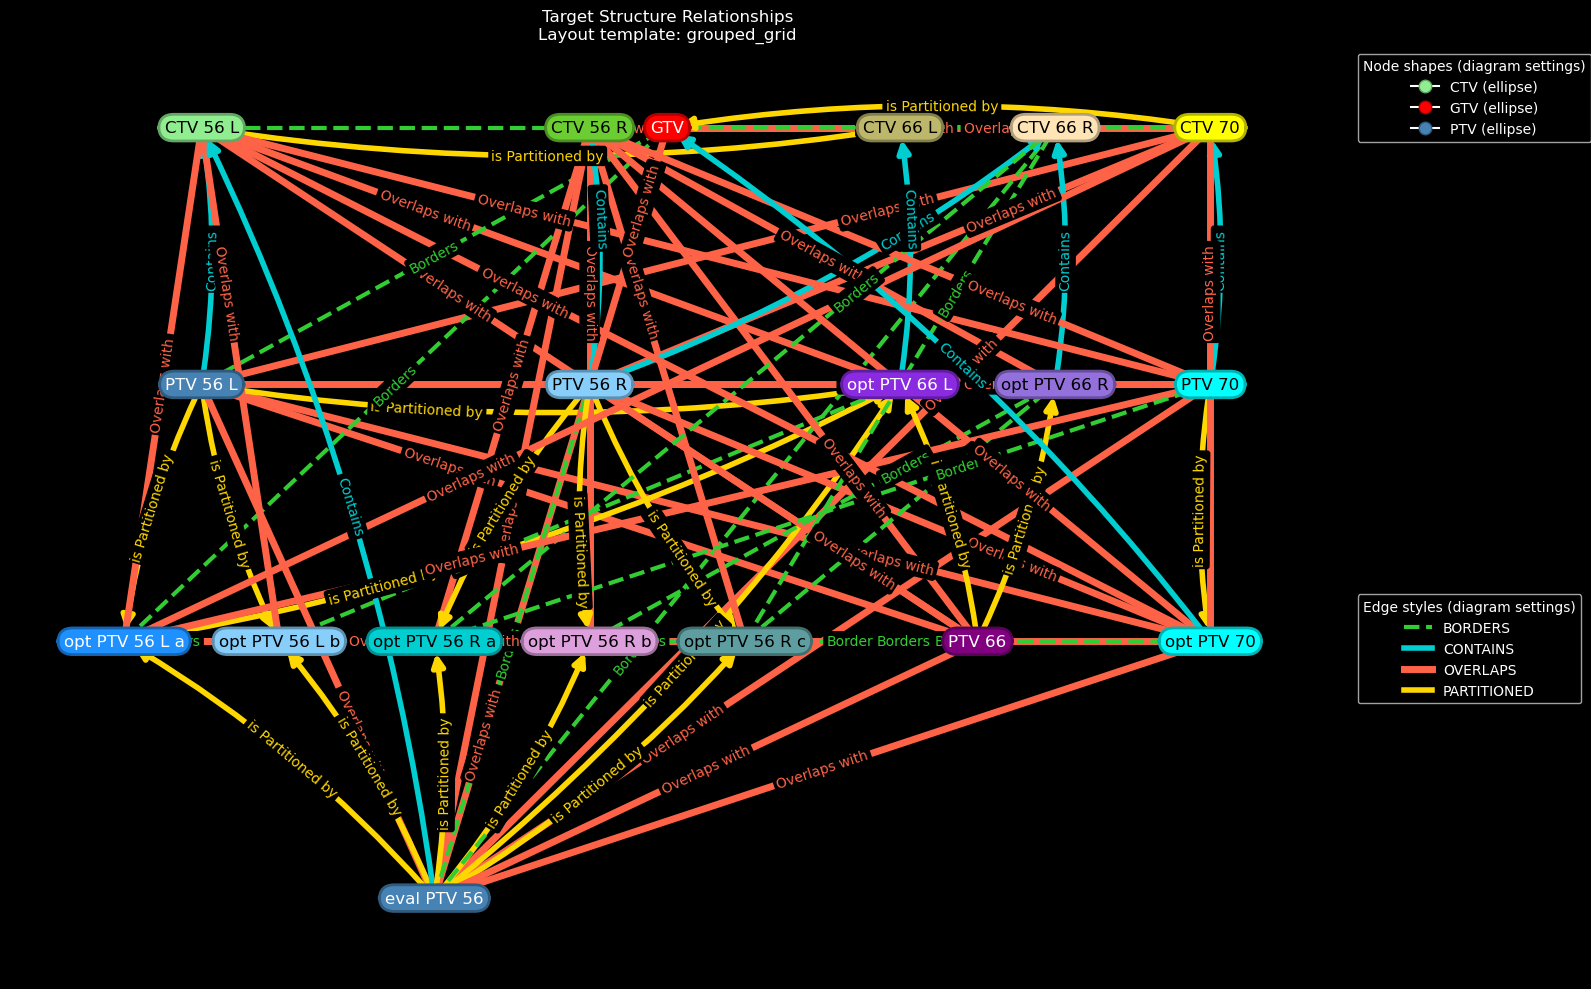

In [9]:
layout_template = get_layout_template('grouped_grid')
module_result = render_template_diagram(
    structure_set=structure_set,
    layout_template=layout_template,
    diagram_settings_path=(
        base_path / 'src' / 'webapp' / 'config' / 'diagram_settings.json'
    ),
    hide_logical_edges=True,
    show_plot=False,
)

apply_crossing_heavy_label_offsets(module_result)
